In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [5]:
#%env PYTHONWARNINGS=error

In [15]:
from hoda.hoda import BTTDA

bttda = BTTDA(
    ranks=[None]*16,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        theta=1,
       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/16...


Forward model :   2%|▏         | 1/64 [00:00<00:04, 13.60it/s]


Fitting block 2/16...


Forward model :   2%|▏         | 1/64 [00:00<00:04, 14.14it/s]


Fitting block 3/16...


...

Fitting block 10/16...


Forward model :   2%|▏         | 1/64 [00:00<00:04, 12.96it/s]


Fitting block 11/16...


/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/cov.py:160: RuntimeWarning: invalid value encountered in scalar divide
  shrinkage = beta / delta
Forward model :   2%|▏         | 1/64 [00:00<00:18,  3.45it/s]


BTTDA(extra_train_info=True,
      hoda_params={'extra_train_info': False, 'max_iter': 64, 'obj': 'tr',
                   'random_state': 42, 'rank': None, 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': False, 'theta': 1,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[None, None, None, None, None, None, None, None, None, None, None,
             None, None, None, None, None],
      verbose=True)

In [16]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(8, 48)",1.855997e-07,0.000330,0.278716,5.598273e-41,5.243130e-31
1,2,"(8, 48)",1.855997e-07,0.000366,0.273672,0.000000e+00,0.000000e+00
2,3,"(8, 48)",1.855997e-07,0.000381,0.272066,0.000000e+00,0.000000e+00
3,4,"(8, 48)",1.855997e-07,0.000389,0.271497,0.000000e+00,0.000000e+00
4,5,"(8, 48)",1.855997e-07,0.000394,0.271364,0.000000e+00,0.000000e+00
5,6,"(8, 48)",1.855997e-07,0.000398,0.271256,0.000000e+00,0.000000e+00
6,7,"(8, 48)",1.855997e-07,0.000401,0.270857,0.000000e+00,0.000000e+00
7,8,"(8, 48)",1.855997e-07,0.000403,0.270921,0.000000e+00,0.000000e+00
8,9,"(8, 48)",1.855997e-07,0.000404,0.271153,0.000000e+00,0.000000e+00
9,10,"(8, 48)",1.855997e-07,0.000406,0.271361,0.000000e+00,0.000000e+00


<Axes: xlabel='block', ylabel='nmse'>

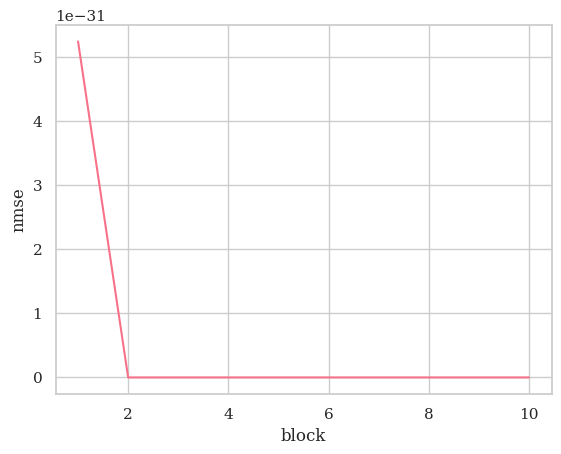

In [17]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='nmse')

In [18]:
from hoda.hoda import forward_stats
info = []
for b in range(len(bttda.blocks_)):
    Xt_test = bttda.transform(X_test, blocks=bttda.blocks_[:b+1])
    X_rec_test = bttda.inv_transform(Xt_test, n_blocks=b+1)
    res = forward_stats(X_test, Xt_test, X_rec_test,y)
    res['block'] =b
    info.append(res)
info = pd.DataFrame(info)
sns.lineplot(data=info, x='block', y='nmse')
info

NameError: name 'X_test' is not defined